<a href="https://colab.research.google.com/github/amann45/AI_Labworks/blob/main/Lab4/pytorch_application_assignment_data2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 4 Assignment on the Data2 [Aman Kumar Ray: ACE080BCT010]

In [546]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [547]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


### Data Preparation

In [548]:
import pandas as pd
import torch
df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [549]:
X = torch.tensor(df['x'].values, dtype=torch.float32)
y = torch.tensor(df['y'].values, dtype=torch.float32)
print(f"X-Shape: {X.shape}")
print(f"y-Shape: {y.shape}")

X-Shape: torch.Size([99])
y-Shape: torch.Size([99])


In [550]:
from sklearn.model_selection import train_test_split

In [551]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [552]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([69]), torch.Size([69]), torch.Size([30]), torch.Size([30]))

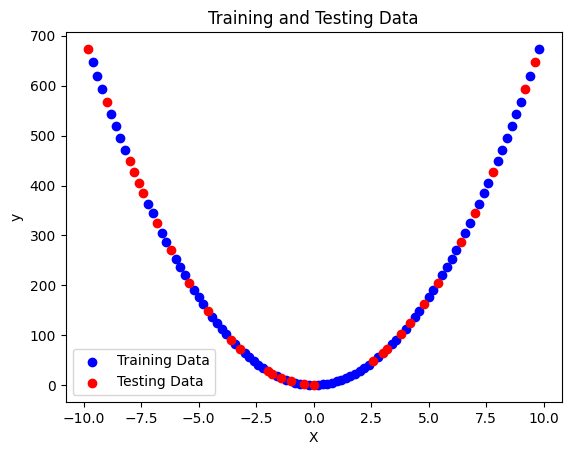

In [553]:
plt.scatter(X_train, y_train, label='Training Data', color='blue')
plt.scatter(X_test, y_test, label='Testing Data', color='red')
plt.title('Training and Testing Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [554]:
import torch.nn as nn

# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x  + self.bias + (3*x)**2 # <- Corrected to a standard linear regression formula (y = mx + b)

In [555]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

In [556]:
print(model_0.weights)
print(model_0.bias)

Parameter containing:
tensor([0.3367], requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)


In [557]:

# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds[:5]

tensor([ 61.8442,  28.6828, 764.9863, 344.0013, 832.8011])

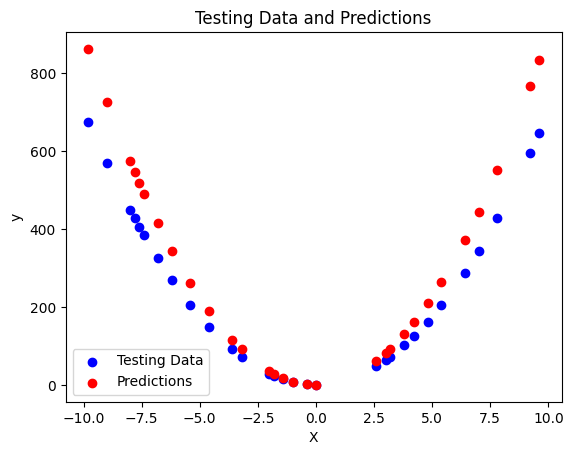

In [558]:
plt.scatter(X_test, y_test, label='Testing Data', color='blue')
plt.scatter(X_test, y_preds, label='Predictions', color='red')
plt.title('Testing Data and Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [559]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [560]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 20000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 63.43925476074219 | MAE Test Loss: 67.06942749023438 
Epoch: 10 | MAE Train Loss: 63.35624694824219 | MAE Test Loss: 67.01073455810547 
Epoch: 20 | MAE Train Loss: 63.27616882324219 | MAE Test Loss: 66.95262908935547 
Epoch: 30 | MAE Train Loss: 63.19906234741211 | MAE Test Loss: 66.89805603027344 
Epoch: 40 | MAE Train Loss: 63.12259292602539 | MAE Test Loss: 66.84386444091797 
Epoch: 50 | MAE Train Loss: 63.046112060546875 | MAE Test Loss: 66.78968811035156 
Epoch: 60 | MAE Train Loss: 62.969627380371094 | MAE Test Loss: 66.73550415039062 
Epoch: 70 | MAE Train Loss: 62.89680099487305 | MAE Test Loss: 66.68209075927734 
Epoch: 80 | MAE Train Loss: 62.82631301879883 | MAE Test Loss: 66.6290054321289 
Epoch: 90 | MAE Train Loss: 62.75580978393555 | MAE Test Loss: 66.575927734375 
Epoch: 100 | MAE Train Loss: 62.68532180786133 | MAE Test Loss: 66.52284240722656 
Epoch: 110 | MAE Train Loss: 62.61482238769531 | MAE Test Loss: 66.46976470947266 
Epoch: 120 | MAE

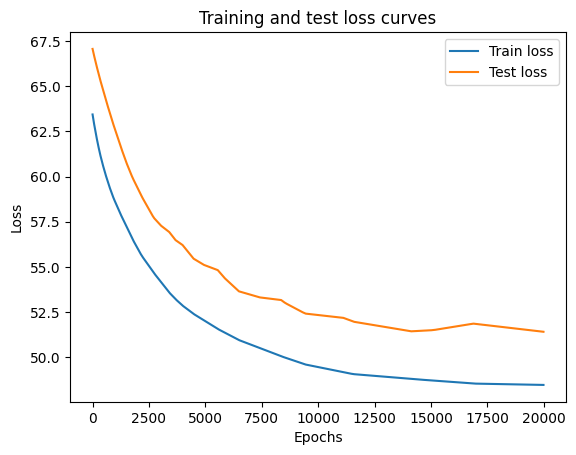

In [561]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [562]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([-1.3012]), 'bias': tensor([-42.4950])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


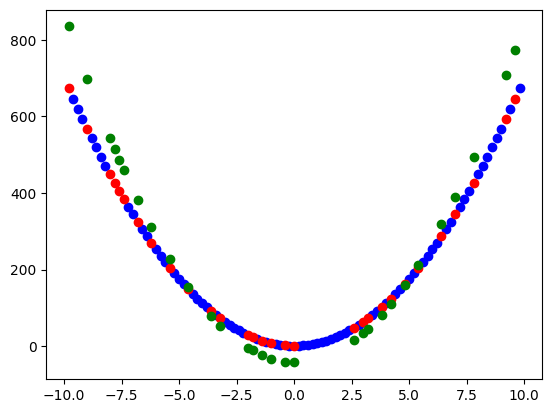

In [563]:
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  y_preds = model_0(X_test)

plt.scatter(X_train, y_train, label='Training Data', color='blue')
plt.scatter(X_test, y_test, label='Testing Data', color='red')
plt.scatter(X_test, y_preds, label='Predictions', color='green')
plt.show()